# Phrase Segmentation on Jazzomat (wjazzd.db)

This notebook turns raw solo-note data into phrase-level musical chunks you can reason about.

If you are a performer, think of a phrase as one spoken musical thought: a short idea with a beginning, direction, and ending.

What we will build:
1. A table where each row is one phrase
2. Basic phrase descriptors (length, pitch span, time span)
3. Harmonic context from the rhythm section (chords/form)
4. Metadata so phrases are linked to player, tune, and recording

By the end, you will have a practical dataset that is ready for feature engineering and comparisons across solos.

In [26]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

## Block 1: Tooling and Display Setup

This cell imports the Python tools we need:

- `sqlite3`: read the Jazzomat database
- `pandas`: table operations (our main data tool)
- `numpy`: numeric helpers
- `matplotlib`: quick visual checks

No musical decisions happen here yet; this is just getting the workbench ready.

In [30]:
ROOT = Path.cwd().resolve()
if (ROOT / 'README.md').exists():
    REPO_ROOT = ROOT
elif (ROOT.parent / 'README.md').exists():
    REPO_ROOT = ROOT.parent
else:
    REPO_ROOT = ROOT

candidates = [
    REPO_ROOT / 'data' / 'wjazzd.db',
    REPO_ROOT / 'wjazzd.db',
    ROOT / 'data' / 'wjazzd.db',
    ROOT.parent / 'data' / 'wjazzd.db',
]
DB_PATH = next((p for p in candidates if p.exists()), None)
OUT_DIR = REPO_ROOT / 'data'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if DB_PATH is None:
    searched = '\n'.join(str(p) for p in candidates)
    raise FileNotFoundError(f'Missing database file. Searched:\n{searched}')

conn = sqlite3.connect(DB_PATH)
print(f'Connected to: {DB_PATH}')

Connected to: C:\Users\grego\Documents\GitHub\jazzomat-app\data\wjazzd.db


In [7]:
def run_sql(query: str, params=None) -> pd.DataFrame:
    params = params or ()
    return pd.read_sql_query(query, conn, params=params)

tables = run_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
tables

,name
0,beats
1,composition_info
2,db_info
3,esac_info
4,melody
5,melody_type
6,popsong_info
7,record_info
8,sections
9,solo_info


## Block 2: Understand the Database Musically

Before segmenting anything, we check what musical annotation layers exist.

In Jazzomat, different tables hold different viewpoints:
- `melody`: the solo line (note events)
- `sections`: analyst labels such as PHRASE, CHORD, FORM, CHORUS
- `beats`: timeline grid with chord/form references
- `solo_info` and related tables: who, what tune, which recording

Conceptually, we are combining three timelines:
1. Melody-note timeline
2. Phrase-label timeline
3. Beat/chord timeline

In [8]:
section_types = run_sql("SELECT DISTINCT type FROM sections ORDER BY type")
section_types

,type
0,CHORD
1,CHORUS
2,FORM
3,IDEA
4,PHRASE


In [9]:
phrase_sections = run_sql("""
WITH phrase_sections AS (
  SELECT
    s.melid,
    CAST(s.value AS TEXT) AS phrase_label,
    s.start AS phrase_start_idx,
    s.end AS phrase_end_idx,
    ROW_NUMBER() OVER (PARTITION BY s.melid ORDER BY s.start, s.end, s.value) AS phrase_num_in_melid,
    printf('%d_%d_%d', s.melid, s.start, s.end) AS phrase_uid
  FROM sections s
  WHERE s.type = 'PHRASE'
)
SELECT * FROM phrase_sections
ORDER BY melid, phrase_start_idx
""")

print('phrase rows:', len(phrase_sections))
phrase_sections.head(10)

phrase rows: 11082


,melid,phrase_label,phrase_start_idx,phrase_end_idx,phrase_num_in_melid,phrase_uid
0,1,1,0,6,1,1_0_6
1,1,2,7,34,2,1_7_34
2,1,3,35,46,3,1_35_46
3,1,4,47,73,4,1_47_73
4,1,5,74,75,5,1_74_75
5,1,6,76,79,6,1_76_79
6,1,7,80,84,7,1_80_84
7,1,8,85,94,8,1_85_94
8,1,9,95,103,9,1_95_103
9,1,10,104,110,10,1_104_110


### Why This Phrase Table Matters

This query pulls only rows labeled `PHRASE` from `sections`.

Each row gives a start and end position inside a solo plus a phrase label. Think of it as the analyst saying:
- "this idea starts here"
- "this idea ends there"

At this stage, we only have phrase boundaries, not the actual notes inside each phrase.

## Block 3: Convert Note Events into a Phrase-Ready Index

Phrase boundaries in `sections` are position-based. Melody notes are event-based.

So we build a clean note counter (`note_idx`) for each solo.

Conceptually:
- event IDs are database identifiers
- note indices are musical positions in order (0th note, 1st note, 2nd note, ...)

This makes phrase boundaries and melody notes speak the same coordinate language.

In [10]:
melody_idx = run_sql("""
SELECT
  m.eventid,
  m.melid,
  m.onset,
  m.pitch,
  m.duration,
  m.bar,
  m.beat,
  ROW_NUMBER() OVER (PARTITION BY m.melid ORDER BY m.eventid) - 1 AS note_idx
FROM melody m
ORDER BY m.melid, m.eventid
""")

print('melody rows:', len(melody_idx))
melody_idx.head()

melody rows: 200809


,eventid,melid,onset,pitch,duration,bar,beat,note_idx
0,1,1,10.343492,65.0,0.138776,0,1,0
1,2,1,10.637642,63.0,0.171247,0,2,1
2,3,1,10.843719,58.0,0.081270,0,2,2
3,4,1,10.948209,61.0,0.235102,0,3,3
4,5,1,11.232653,63.0,0.130612,0,4,4


In [31]:
phrase_notes = run_sql("""
WITH phrase_sections AS (
  SELECT
    s.melid,
    CAST(s.value AS TEXT) AS phrase_label,
    s.start AS phrase_start_idx,
    s.end AS phrase_end_idx,
    ROW_NUMBER() OVER (PARTITION BY s.melid ORDER BY s.start, s.end, s.value) AS phrase_num_in_melid,
    printf('%d_%d_%d', s.melid, s.start, s.end) AS phrase_uid
  FROM sections s
  WHERE s.type = 'PHRASE'
),
melody_idx AS (
  SELECT
    m.eventid,
    m.melid,
    m.onset,
    m.pitch,
    m.duration,
    m.bar,
    m.beat,
    ROW_NUMBER() OVER (PARTITION BY m.melid ORDER BY m.eventid) - 1 AS note_idx
  FROM melody m
)
SELECT
  ps.phrase_uid,
  ps.melid,
  ps.phrase_num_in_melid,
  ps.phrase_label,
  ps.phrase_start_idx,
  ps.phrase_end_idx,
  mi.eventid,
  mi.note_idx,
  mi.onset,
  mi.pitch,
  mi.duration,
  mi.bar,
  mi.beat
FROM phrase_sections ps
LEFT JOIN melody_idx mi
  ON mi.melid = ps.melid
 AND mi.note_idx >= ps.phrase_start_idx
 AND mi.note_idx < ps.phrase_end_idx
ORDER BY ps.melid, ps.phrase_start_idx, mi.note_idx
""")

print('phrase-note rows:', len(phrase_notes))
print('unique phrases:', phrase_notes['phrase_uid'].nunique())
phrase_notes.head(10)

phrase-note rows: 189785
unique phrases: 11082


,phrase_uid,melid,phrase_num_in_melid,phrase_label,phrase_start_idx,phrase_end_idx,eventid,note_idx,onset,pitch,duration,bar,beat
0,1_0_6,1,1,1,0,6,1.0,0.0,10.343492,65.0,0.138776,0.0,1.0
1,1_0_6,1,1,1,0,6,2.0,1.0,10.637642,63.0,0.171247,0.0,2.0
2,1_0_6,1,1,1,0,6,3.0,2.0,10.843719,58.0,0.081270,0.0,2.0
3,1_0_6,1,1,1,0,6,4.0,3.0,10.948209,61.0,0.235102,0.0,3.0
4,1_0_6,1,1,1,0,6,5.0,4.0,11.232653,63.0,0.130612,0.0,4.0
5,1_0_6,1,1,1,0,6,6.0,5.0,11.551927,58.0,0.188662,1.0,1.0
6,1_7_34,1,2,2,7,34,8.0,7.0,14.535692,50.0,0.159637,3.0,3.0
7,1_7_34,1,2,2,7,34,9.0,8.0,14.799819,57.0,0.145125,3.0,4.0
8,1_7_34,1,2,2,7,34,10.0,9.0,14.973968,60.0,0.110295,3.0,4.0
9,1_7_34,1,2,2,7,34,11.0,10.0,15.116190,58.0,0.130612,4.0,1.0


## Block 3B: Add Harmonic Context to Each Note

Melody alone is only half the story. In this next code block we attach beat-level annotations to each note onset.

Result: each phrase note also carries chord, form, and chorus context.

That gives us phrase content plus harmonic ground, which is what players actually hear and react to.

In [32]:
beats = run_sql("""
SELECT
  melid, onset AS beat_onset, bar AS beat_bar, beat AS beat_in_bar,
  signature, chord, form, chorus_id
FROM beats
ORDER BY melid, beat_onset
""")

# merge_asof cannot handle null merge keys, so we process only note rows with valid onsets
pn_valid = phrase_notes.dropna(subset=['onset']).copy()

merged_parts = []
for melid, notes_g in pn_valid.groupby('melid', sort=False):
    beats_g = beats.loc[beats['melid'] == melid].copy()
    notes_g = notes_g.sort_values('onset')
    beats_g = beats_g.sort_values('beat_onset').drop(columns=['melid'])

    if beats_g.empty:
        # Keep note rows even if this melid has no beats annotation
        notes_tmp = notes_g.copy()
        notes_tmp['beat_onset'] = np.nan
        notes_tmp['beat_bar'] = np.nan
        notes_tmp['beat_in_bar'] = np.nan
        notes_tmp['signature'] = np.nan
        notes_tmp['chord'] = np.nan
        notes_tmp['form'] = np.nan
        notes_tmp['chorus_id'] = np.nan
        merged_parts.append(notes_tmp)
        continue

    merged = pd.merge_asof(
        notes_g,
        beats_g,
        left_on='onset',
        right_on='beat_onset',
        direction='backward'
    )
    merged['melid'] = melid
    merged_parts.append(merged)

phrase_notes_ctx = pd.concat(merged_parts, ignore_index=True)
phrase_notes_ctx = phrase_notes_ctx.sort_values(['melid', 'onset', 'note_idx']).reset_index(drop=True)

phrase_notes_ctx.head(10)

,phrase_uid,melid,phrase_num_in_melid,phrase_label,phrase_start_idx,phrase_end_idx,eventid,note_idx,onset,pitch,duration,bar,beat,beat_onset,beat_bar,beat_in_bar,signature,chord,form,chorus_id
0,1_0_6,1,1,1,0,6,1.0,0.0,10.343492,65.0,0.138776,0.0,1.0,10.339796,0,1,,Bb6,,0
1,1_0_6,1,1,1,0,6,2.0,1.0,10.637642,63.0,0.171247,0.0,2.0,10.631542,0,2,,,,0
2,1_0_6,1,1,1,0,6,3.0,2.0,10.843719,58.0,0.081270,0.0,2.0,10.631542,0,2,,,,0
3,1_0_6,1,1,1,0,6,4.0,3.0,10.948209,61.0,0.235102,0.0,3.0,10.918163,0,3,,,,0
4,1_0_6,1,1,1,0,6,5.0,4.0,11.232653,63.0,0.130612,0.0,4.0,11.217007,0,4,,,,0
5,1_0_6,1,1,1,0,6,6.0,5.0,11.551927,58.0,0.188662,1.0,1.0,11.514127,1,1,4/4,Bb6,A1,1
6,1_7_34,1,2,2,7,34,8.0,7.0,14.535692,50.0,0.159637,3.0,3.0,14.477234,3,3,,G-7,,1
7,1_7_34,1,2,2,7,34,9.0,8.0,14.799819,57.0,0.145125,3.0,4.0,14.747211,3,4,,,,1
8,1_7_34,1,2,2,7,34,10.0,9.0,14.973968,60.0,0.110295,3.0,4.0,14.747211,3,4,,,,1
9,1_7_34,1,2,2,7,34,11.0,10.0,15.116190,58.0,0.130612,4.0,1.0,15.050295,4,1,,C-7,,1


## Block 4: Collapse Notes into Phrase-Level Rows

The next block summarizes note-level data into one record per phrase.

Think of each output row as a phrase profile card:
- phrase size and span
- pitch range
- chord/form path
- performer and tune metadata

This is the key table for later musical comparisons and feature engineering.

In [35]:
def ordered_unique_nonempty(values):
    seen = set()
    out = []
    for v in values:
        if pd.isna(v):
            continue
        txt = str(v).strip()
        if not txt:
            continue
        if txt not in seen:
            seen.add(txt)
            out.append(txt)
    return out

def first_nonempty(values):
    vals = ordered_unique_nonempty(values)
    return vals[0] if vals else np.nan

phrase_segments_nonempty = (
    phrase_notes_ctx
    .groupby(['phrase_uid', 'melid', 'phrase_num_in_melid', 'phrase_label', 'phrase_start_idx', 'phrase_end_idx'], as_index=False)
    .agg(
        note_count=('eventid', 'count'),
        onset_start=('onset', 'min'),
        onset_end=('onset', 'max'),
        duration_sum=('duration', 'sum'),
        min_pitch=('pitch', 'min'),
        max_pitch=('pitch', 'max'),
        start_bar=('bar', 'min'),
        end_bar=('bar', 'max'),
        start_beat_in_bar=('beat_in_bar', 'min'),
        start_signature=('signature', first_nonempty),
        chorus_id=('chorus_id', 'min'),
        start_chord=('chord', first_nonempty),
        start_form=('form', first_nonempty),
        chords=('chord', lambda s: ' | '.join(ordered_unique_nonempty(s))),
        forms=('form', lambda s: ' | '.join(ordered_unique_nonempty(s))),
    )
)

# Keep every phrase section, even if it has no matched notes
phrase_segments = phrase_sections.merge(
    phrase_segments_nonempty,
    on=['phrase_uid', 'melid', 'phrase_num_in_melid', 'phrase_label', 'phrase_start_idx', 'phrase_end_idx'],
    how='left'
)

phrase_segments['note_count'] = phrase_segments['note_count'].fillna(0).astype(int)
phrase_segments['duration_sum'] = phrase_segments['duration_sum'].fillna(0.0)
phrase_segments['onset_span'] = phrase_segments['onset_end'] - phrase_segments['onset_start']
phrase_segments['pitch_range'] = phrase_segments['max_pitch'] - phrase_segments['min_pitch']

solo_meta = run_sql("""
SELECT
  si.melid,
  si.performer,
  si.title AS solo_title,
  si.instrument,
  si.style,
  si.key AS solo_key,
  si.signature AS solo_signature,
  ci.title AS composition_title,
  ci.form AS composition_form,
  ci.tonalitytype,
  ci.genre,
  ri.artist AS record_artist,
  ri.recordtitle
FROM solo_info si
LEFT JOIN composition_info ci ON ci.compid = si.compid
LEFT JOIN record_info ri ON ri.recordid = si.recordid
""")

phrase_segments = phrase_segments.merge(solo_meta, on='melid', how='left')

# Beat-level signature can be empty in WJD, so keep a robust phrase-level meter value.
phrase_segments['meter_signature'] = phrase_segments['start_signature'].replace('', np.nan)
phrase_segments['meter_signature'] = phrase_segments['meter_signature'].fillna(phrase_segments['solo_signature'])

print('phrase_segments rows:', len(phrase_segments))
phrase_segments.head(10)

phrase_segments rows: 11082


,melid,phrase_label,phrase_start_idx,phrase_end_idx,phrase_num_in_melid,phrase_uid,note_count,onset_start,onset_end,duration_sum,min_pitch,max_pitch,start_bar,end_bar,start_beat_in_bar,start_signature,chorus_id,start_chord,start_form,chords,forms,onset_span,pitch_range,performer,solo_title,instrument,style,solo_key,solo_signature,composition_title,composition_form,tonalitytype,genre,record_artist,recordtitle,meter_signature
0,1,1,0,6,1,1_0_6,6,10.343492,11.551927,0.945669,58.0,65.0,0.0,1.0,1.0,4/4,0.0,Bb6,A1,Bb6,A1,1.208435,7.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
1,1,2,7,34,2,1_7_34,27,14.535692,18.979592,3.815057,50.0,62.0,3.0,7.0,1.0,NaN,1.0,G-7,NaN,G-7 | C-7 | F7 | F-7 | Bb7 | Eb7 | Ab7 | D-7,,4.443900,12.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
2,1,3,35,46,3,1_35_46,11,20.977551,22.591837,1.188776,55.0,65.0,9.0,10.0,1.0,NaN,1.0,Bb6,A2,Bb6 | G7 | C-7 | F7,A2,1.614286,10.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
3,1,4,47,73,4,1_47_73,26,23.721429,27.967710,3.606327,50.0,68.0,11.0,15.0,1.0,NaN,1.0,G-7,NaN,G-7 | C-7 | F7 | F-7 | Bb7 | Eb7,,4.246281,18.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
4,1,5,74,75,5,1_74_75,1,29.908163,29.908163,0.157143,62.0,62.0,16.0,16.0,4.0,NaN,1.0,NaN,NaN,,,0.000000,0.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
5,1,6,76,79,6,1_76_79,3,31.085714,31.563900,0.330884,60.0,64.0,18.0,18.0,1.0,NaN,1.0,NaN,NaN,,,0.478186,4.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
6,1,7,80,84,7,1_80_84,4,32.726531,33.338050,0.505941,59.0,67.0,19.0,20.0,1.0,NaN,1.0,NaN,NaN,,,0.611519,8.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
7,1,8,85,94,8,1_85_94,9,35.029592,36.170408,1.191837,64.0,74.0,21.0,22.0,1.0,NaN,1.0,NaN,NaN,,,1.140816,10.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
8,1,9,95,103,9,1_95_103,8,37.243878,38.386939,1.036735,57.0,67.0,23.0,24.0,2.0,NaN,1.0,NaN,NaN,,,1.143061,10.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4
9,1,10,104,110,10,1_104_110,6,39.687256,40.642177,0.812698,60.0,70.0,25.0,26.0,1.0,NaN,1.0,G7,NaN,G7 | C-7 | F7,,0.954921,10.0,Art Pepper,Anthropology,cl,COOL,Bb-maj,4/4,Anthropology,A8A8B8A8,FUNCTIONAL,ORIGINAL,Art Pepper,"Art Pepper, The Compelete Galaxy Recordings, CD 4",4/4


## Block 5: Sanity Checks on the Phrase Table

Before plotting or exporting, we run quick numerical checks.

Purpose: confirm segmentation quality and catch obvious pipeline issues (for example, phrases with zero notes).

This is a practical reality check before trusting downstream analyses.

In [19]:
empty_note_phrases = (phrase_segments['note_count'] == 0).sum()
print('phrases with 0 notes:', int(empty_note_phrases))

summary = phrase_segments[['note_count', 'onset_span', 'duration_sum', 'pitch_range']].describe().T
summary

phrases with 0 notes: 58


,count,mean,std,min,25%,50%,75%,max
note_count,11082.0,17.120285,15.442312,0.0,7.000000,12.000000,23.000000,202.000000
onset_span,11024.0,2.747915,2.392871,0.0,1.027483,2.132608,3.824433,26.505102
duration_sum,11082.0,2.363986,1.924437,0.0,0.960726,1.869388,3.283713,18.612154
pitch_range,11024.0,12.464532,6.853240,0.0,7.000000,12.000000,17.000000,45.000000


## Block 6: Visual Distribution Check

The next plot cell gives a quick feel for dataset shape.

Left histogram: how long phrases are in note count.
Right histogram: how long phrases last in time.

As a musician, this helps you see whether the phrase population looks plausible for improvised language.

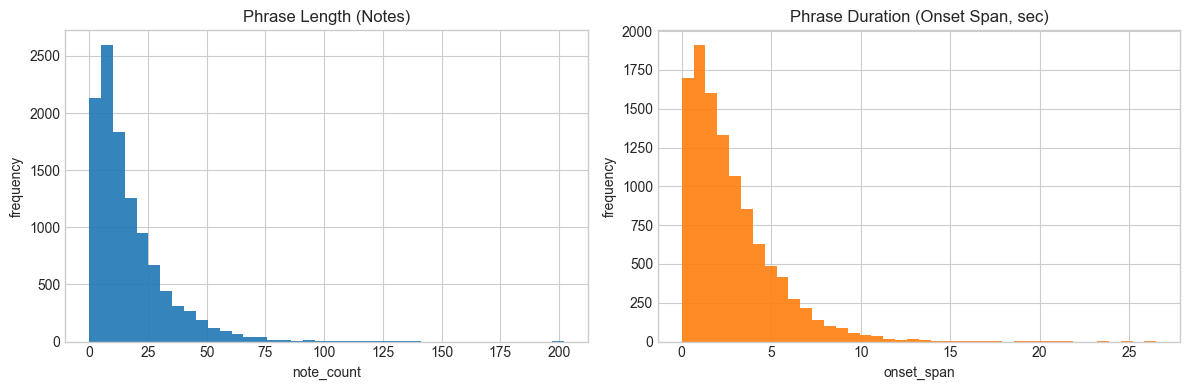

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(phrase_segments['note_count'].dropna(), bins=40, color='#1f77b4', alpha=0.9)
axes[0].set_title('Phrase Length (Notes)')
axes[0].set_xlabel('note_count')
axes[0].set_ylabel('frequency')

axes[1].hist(phrase_segments['onset_span'].dropna(), bins=40, color='#ff7f0e', alpha=0.9)
axes[1].set_title('Phrase Duration (Onset Span, sec)')
axes[1].set_xlabel('onset_span')
axes[1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

Export for Reuse

In [36]:
csv_path = OUT_DIR / 'phrase_segments_preview.csv'
parquet_path = OUT_DIR / 'phrase_segments_preview.parquet'

phrase_segments.to_csv(csv_path, index=False)
print(f'Wrote CSV: {csv_path}')

try:
    phrase_segments.to_parquet(parquet_path, index=False)
    print(f'Wrote Parquet: {parquet_path}')
except Exception as exc:
    print('Parquet export skipped (install pyarrow or fastparquet):', exc)

Wrote CSV: C:\Users\grego\Documents\GitHub\jazzomat-app\data\phrase_segments_preview.csv
Parquet export skipped (install pyarrow or fastparquet): Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.


In [22]:
conn.close()
print('Connection closed.')

Connection closed.
